In [182]:
import fastf1


results = {}

schedule = fastf1.get_event_schedule(2024)


for race in schedule['EventName'].unique(): 
    session = fastf1.get_session(2024, race, 'Q')
    session.load()

    results[race] = session.results[['Abbreviation', 'TeamName', "Q1", "Q2", "Q3", "Position"]]


print(results)


logger      WARNING 	Failed to load schedule from FastF1 backend!


req            INFO 	Using cached data for season_schedule
core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '44', '63', '16', '55', '10', '11', '31', '81', '14', '77', '27', '18', '24', '20', '22', '3', '23', '2']
core           INFO 	Loading data for Austrian Gra

{'Spanish Grand Prix':    Abbreviation         TeamName                     Q1  \
4           NOR          McLaren 0 days 00:01:12.386000   
1           VER  Red Bull Racing 0 days 00:01:12.306000   
44          HAM         Mercedes 0 days 00:01:12.143000   
63          RUS         Mercedes 0 days 00:01:12.456000   
16          LEC          Ferrari 0 days 00:01:12.257000   
55          SAI          Ferrari 0 days 00:01:12.403000   
10          GAS           Alpine 0 days 00:01:12.651000   
11          PER  Red Bull Racing 0 days 00:01:12.477000   
31          OCO           Alpine 0 days 00:01:12.691000   
81          PIA          McLaren 0 days 00:01:12.460000   
14          ALO     Aston Martin 0 days 00:01:12.505000   
77          BOT      Kick Sauber 0 days 00:01:12.758000   
27          HUL     Haas F1 Team 0 days 00:01:12.708000   
18          STR     Aston Martin 0 days 00:01:12.881000   
24          ZHO      Kick Sauber 0 days 00:01:12.880000   
20          MAG     Haas F1 Team 

In [183]:
import pandas as pd 

for race, df in results.items(): 
    df['Race'] = race

combined_df = pd.concat(results.values())


combined_df.to_csv("qualifying_results.csv", index=False)

df = pd.read_csv('qualifying_results.csv')

df.head()

/var/folders/06/7h6tpl3553lbp4vlf331z8z80000gn/T/ipykernel_5584/3748828827.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Race'] = race
/var/folders/06/7h6tpl3553lbp4vlf331z8z80000gn/T/ipykernel_5584/3748828827.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Race'] = race


,Abbreviation,TeamName,Q1,Q2,Q3,Position,Race
0,NOR,McLaren,0 days 00:01:12.386000,0 days 00:01:11.872000,0 days 00:01:11.383000,1.0,Spanish Grand Prix
1,VER,Red Bull Racing,0 days 00:01:12.306000,0 days 00:01:11.653000,0 days 00:01:11.403000,2.0,Spanish Grand Prix
2,HAM,Mercedes,0 days 00:01:12.143000,0 days 00:01:11.792000,0 days 00:01:11.701000,3.0,Spanish Grand Prix
3,RUS,Mercedes,0 days 00:01:12.456000,0 days 00:01:11.812000,0 days 00:01:11.703000,4.0,Spanish Grand Prix
4,LEC,Ferrari,0 days 00:01:12.257000,0 days 00:01:12.038000,0 days 00:01:11.731000,5.0,Spanish Grand Prix


In [184]:
races = df['Race'].unique()
drivers = df['Abbreviation'].unique()

qualy = {}

def safe_time_to_seconds(t):
    if pd.isna(t) or t in ['', '-', None]:
        return 0.0
    try:
        # convert to timedelta 
        if isinstance(t, str): 
            t = pd.to_timedelta(t)
        # If it's already a Timedelta → total_seconds
        if hasattr(t, 'total_seconds'):
            return t.total_seconds()
        # Else assume string "M:SS.sss" → parse
        if isinstance(t, str):
            m, s = t.split(":")
            return int(m) * 60 + float(s)
    except Exception as e:
        print(f"Failed to parse time: {t} ({e})")
        return 0.0

for race in races:
    for driver in drivers:

        # You need to define the series INSIDE the loop
        Q1_series = df[(df['Abbreviation'] == driver) & (df['Race'] == race)]['Q1']
        Q2_series = df[(df['Abbreviation'] == driver) & (df['Race'] == race)]['Q2']
        Q3_series = df[(df['Abbreviation'] == driver) & (df['Race'] == race)]['Q3']

        if not Q1_series.empty and not Q2_series.empty and not Q3_series.empty:


            Q1_value = safe_time_to_seconds(Q1_series.values[0])
            Q2_value = safe_time_to_seconds(Q2_series.values[0])
            Q3_value = safe_time_to_seconds(Q3_series.values[0])

            if driver not in qualy:
                qualy[driver] = []

            # Append this race result
            qualy[driver].append({
                race: {'Q1': Q1_value, 'Q2': Q2_value, 'Q3': Q3_value}
            })
        else:
            continue

# Pretty print result
import json
print(json.dumps(qualy, indent=2))


{
  "NOR": [
    {
      "Spanish Grand Prix": {
        "Q1": 72.386,
        "Q2": 71.872,
        "Q3": 71.383
      }
    },
    {
      "Austrian Grand Prix": {
        "Q1": 65.45,
        "Q2": 65.103,
        "Q3": 64.718
      }
    },
    {
      "British Grand Prix": {
        "Q1": 91.596,
        "Q2": 86.559,
        "Q3": 86.03
      }
    },
    {
      "Hungarian Grand Prix": {
        "Q1": 77.755,
        "Q2": 75.54,
        "Q3": 75.227
      }
    },
    {
      "Belgian Grand Prix": {
        "Q1": 115.582,
        "Q2": 114.358,
        "Q3": 113.981
      }
    },
    {
      "Dutch Grand Prix": {
        "Q1": 71.377,
        "Q2": 70.496,
        "Q3": 69.673
      }
    },
    {
      "Italian Grand Prix": {
        "Q1": 79.911,
        "Q2": 79.727,
        "Q3": 79.327
      }
    },
    {
      "Azerbaijan Grand Prix": {
        "Q1": 103.609,
        "Q2": 0.0,
        "Q3": 0.0
      }
    },
    {
      "Singapore Grand Prix": {
        "Q1": 90.002,


In [185]:
# convert the qualy data into tabular format for processing 
rows = [] 
for driver, races in qualy.items(): 
    for race_data in races: 
        for race, times in race_data.items(): 
            row = { 
                "Driver": driver, 
                "Race": race,
                "Q1": times['Q1'],
                "Q2": times['Q2'],
                "Q3": times['Q3'],
            }
            rows.append(row)

print(json.dumps(rows, indent=2))
df_qualy = pd.DataFrame(rows)

[
  {
    "Driver": "NOR",
    "Race": "Spanish Grand Prix",
    "Q1": 72.386,
    "Q2": 71.872,
    "Q3": 71.383
  },
  {
    "Driver": "NOR",
    "Race": "Austrian Grand Prix",
    "Q1": 65.45,
    "Q2": 65.103,
    "Q3": 64.718
  },
  {
    "Driver": "NOR",
    "Race": "British Grand Prix",
    "Q1": 91.596,
    "Q2": 86.559,
    "Q3": 86.03
  },
  {
    "Driver": "NOR",
    "Race": "Hungarian Grand Prix",
    "Q1": 77.755,
    "Q2": 75.54,
    "Q3": 75.227
  },
  {
    "Driver": "NOR",
    "Race": "Belgian Grand Prix",
    "Q1": 115.582,
    "Q2": 114.358,
    "Q3": 113.981
  },
  {
    "Driver": "NOR",
    "Race": "Dutch Grand Prix",
    "Q1": 71.377,
    "Q2": 70.496,
    "Q3": 69.673
  },
  {
    "Driver": "NOR",
    "Race": "Italian Grand Prix",
    "Q1": 79.911,
    "Q2": 79.727,
    "Q3": 79.327
  },
  {
    "Driver": "NOR",
    "Race": "Azerbaijan Grand Prix",
    "Q1": 103.609,
    "Q2": 0.0,
    "Q3": 0.0
  },
  {
    "Driver": "NOR",
    "Race": "Singapore Grand Prix",
  

In [186]:
df_qualy.head()

,Driver,Race,Q1,Q2,Q3
0,NOR,Spanish Grand Prix,72.386,71.872,71.383
1,NOR,Austrian Grand Prix,65.450,65.103,64.718
2,NOR,British Grand Prix,91.596,86.559,86.030
3,NOR,Hungarian Grand Prix,77.755,75.540,75.227
4,NOR,Belgian Grand Prix,115.582,114.358,113.981


In [187]:
# If the driver has null values make sure they are 0 
df_qualy.isnull().sum()

Driver    0
Race      0
Q1        0
Q2        0
Q3        0
dtype: int64

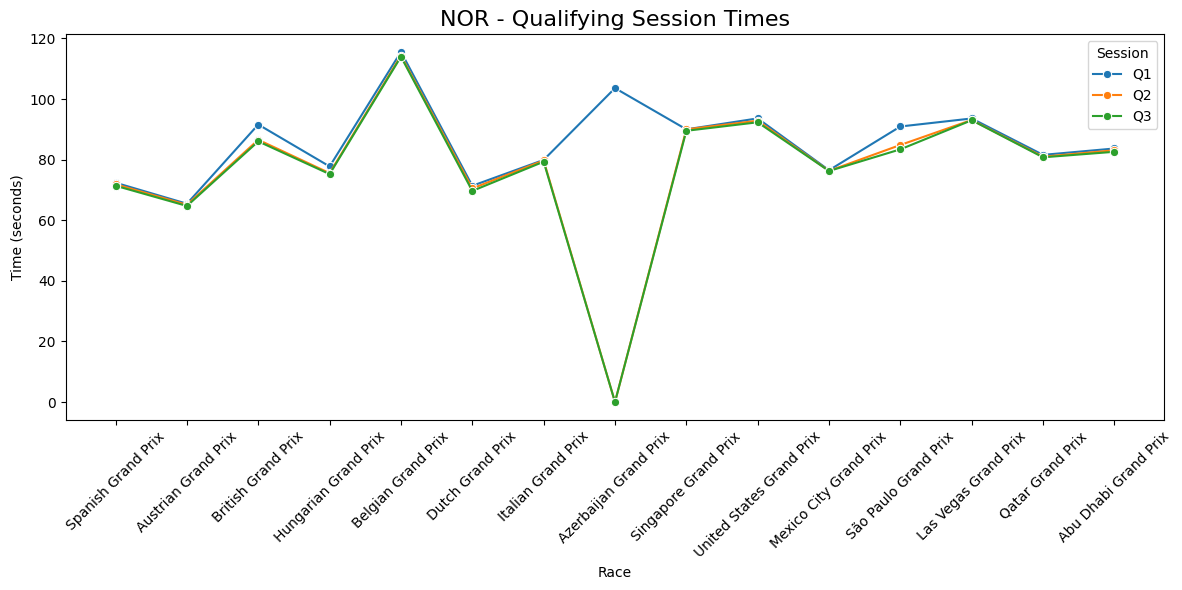

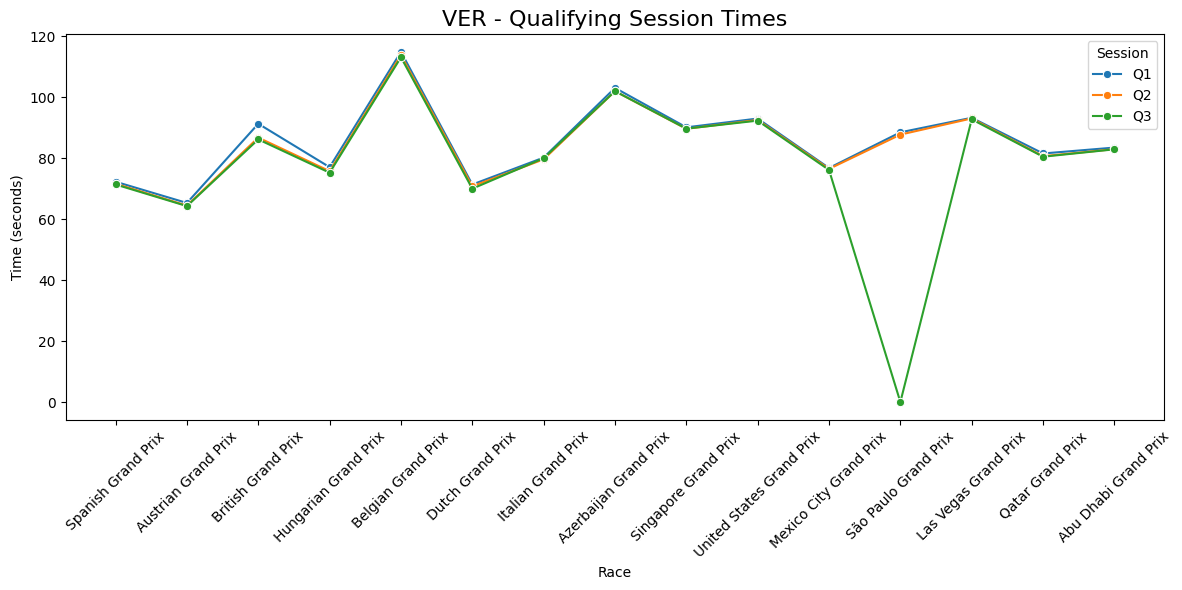

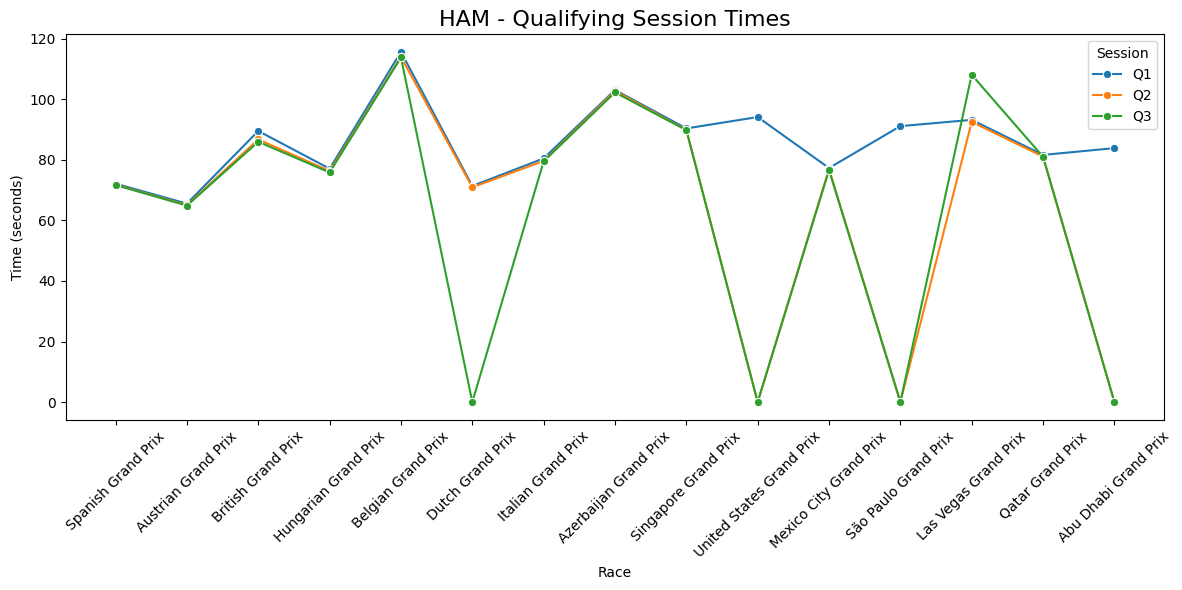

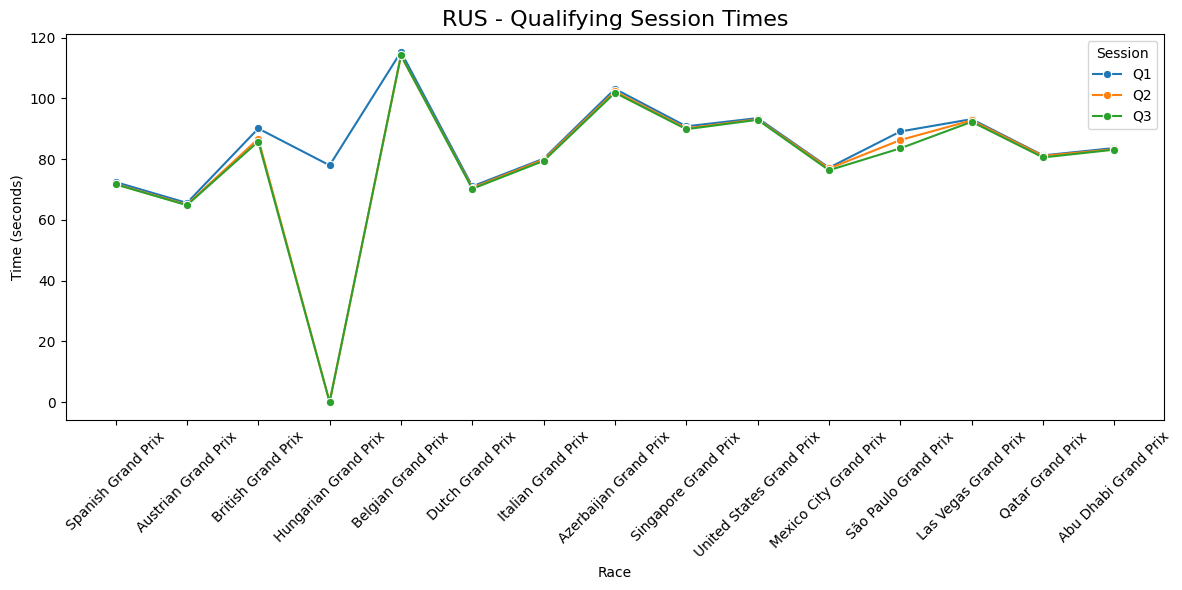

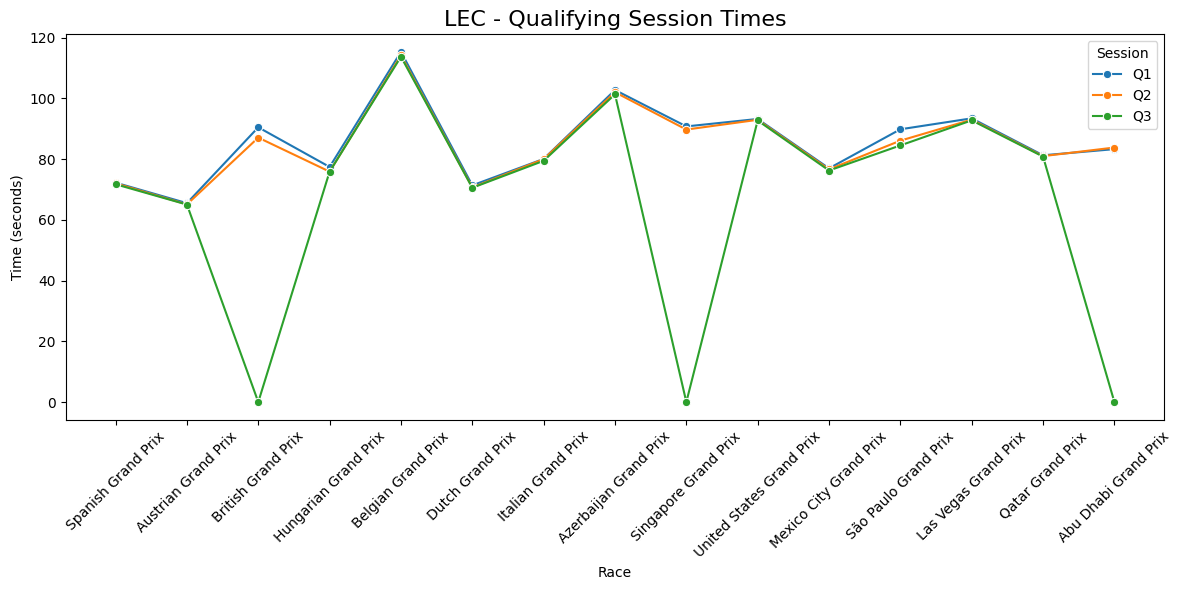

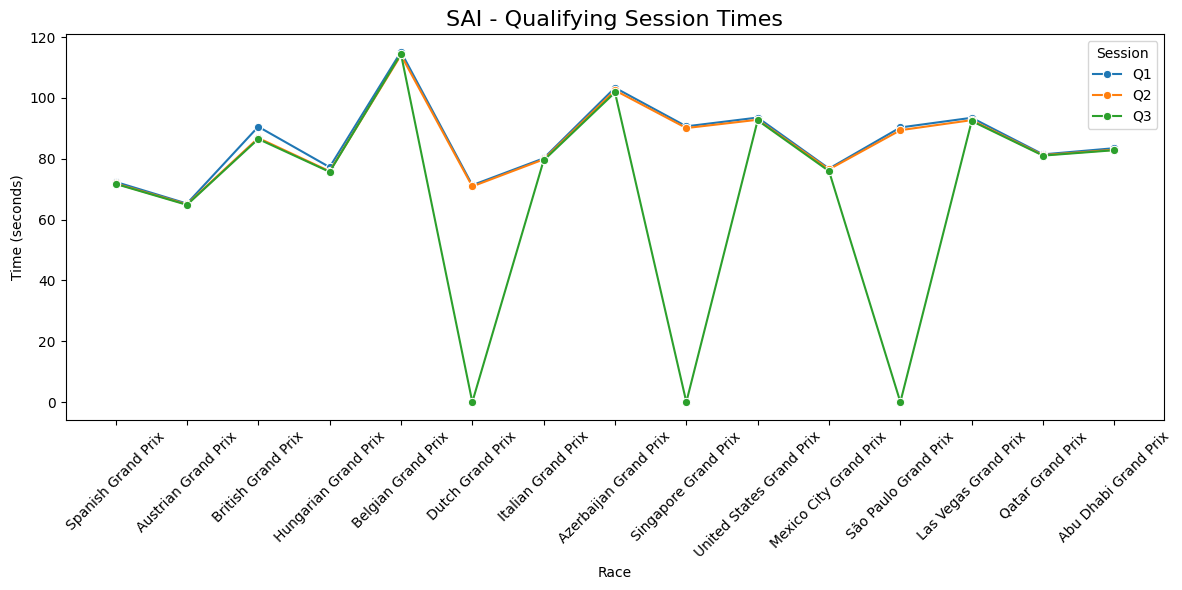

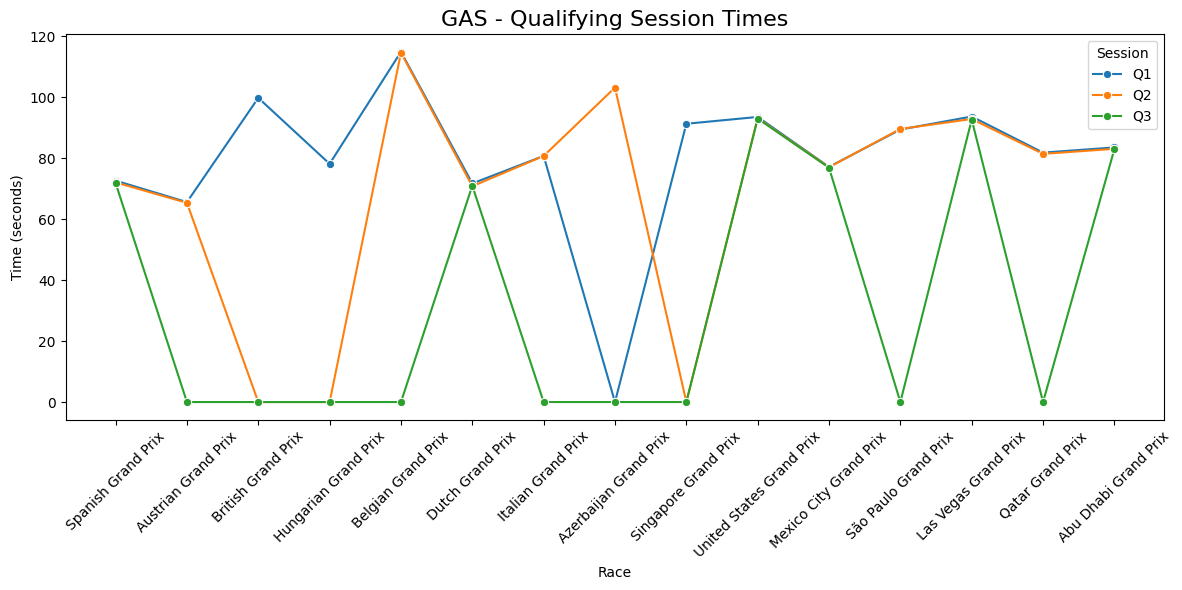

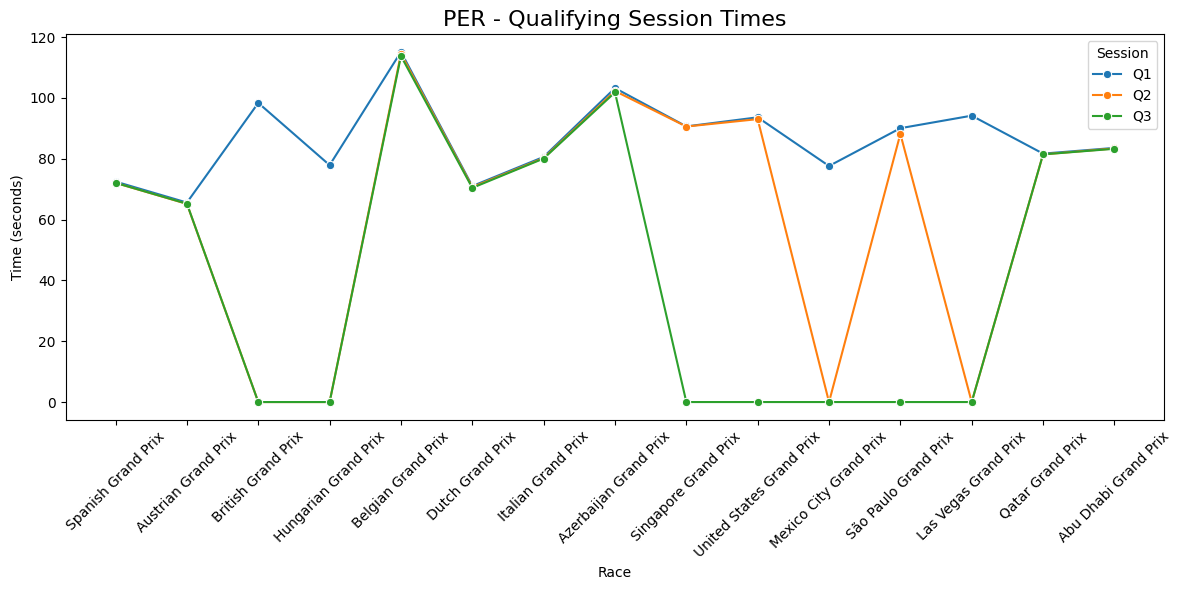

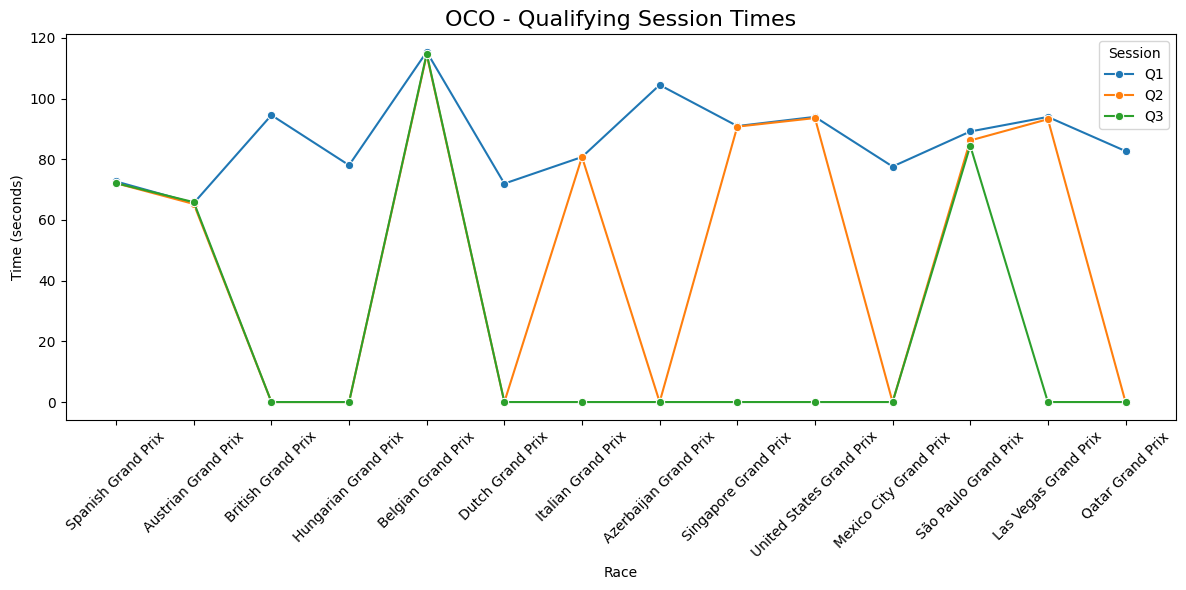

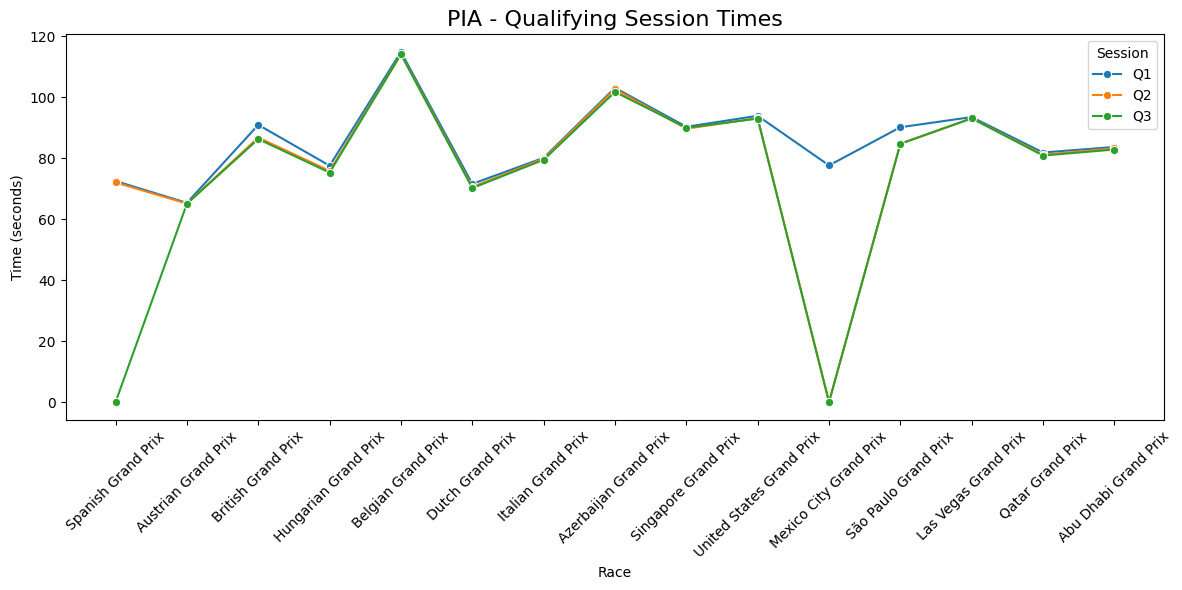

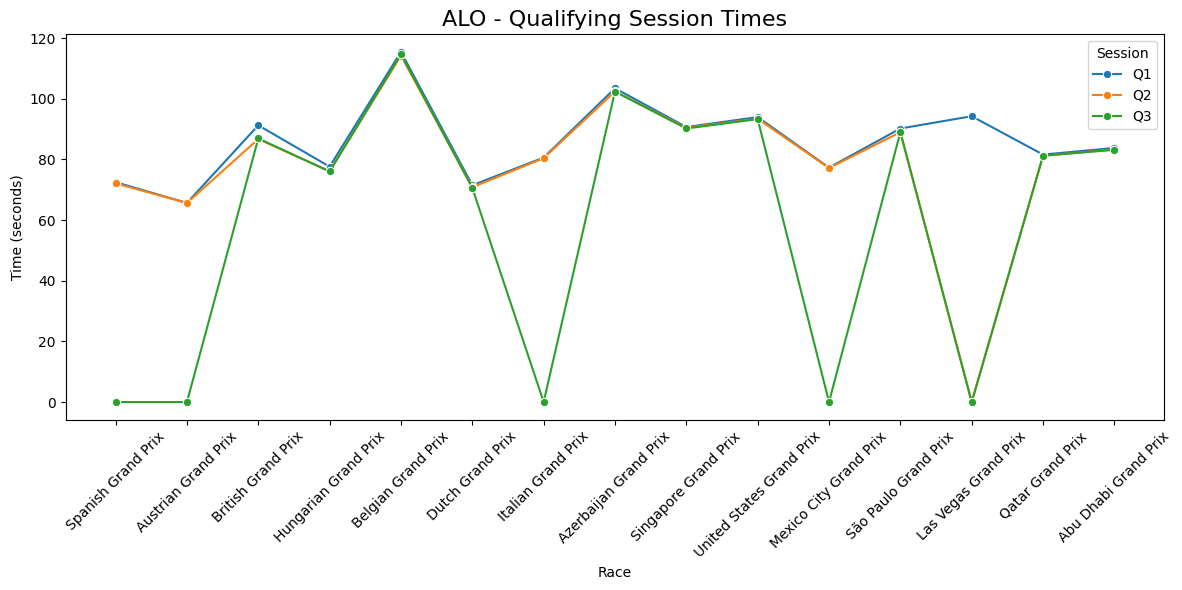

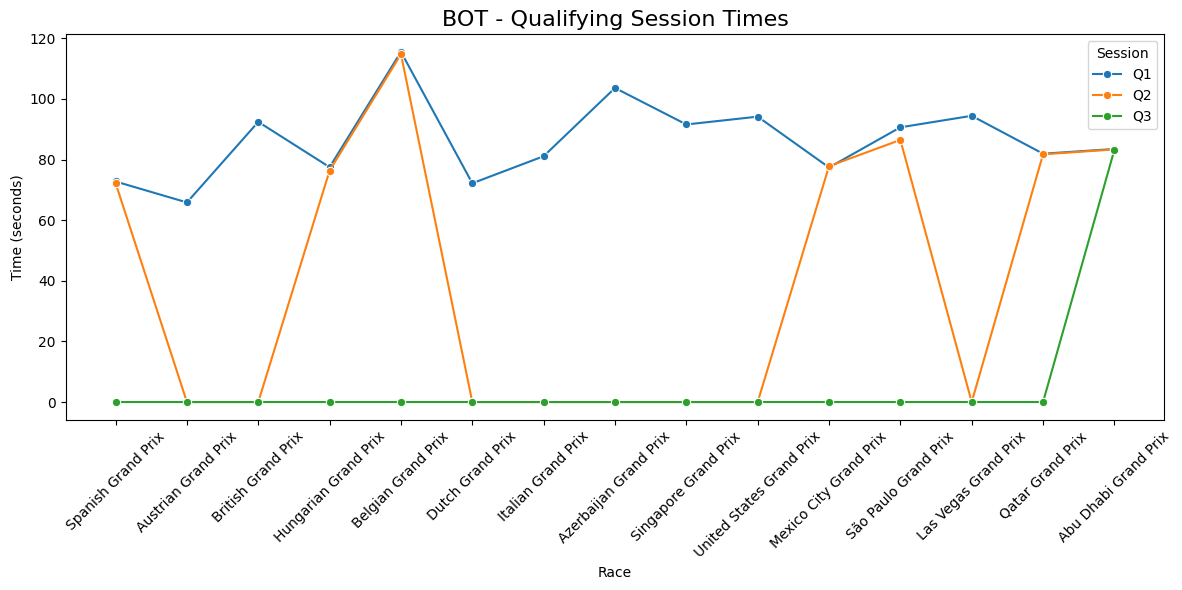

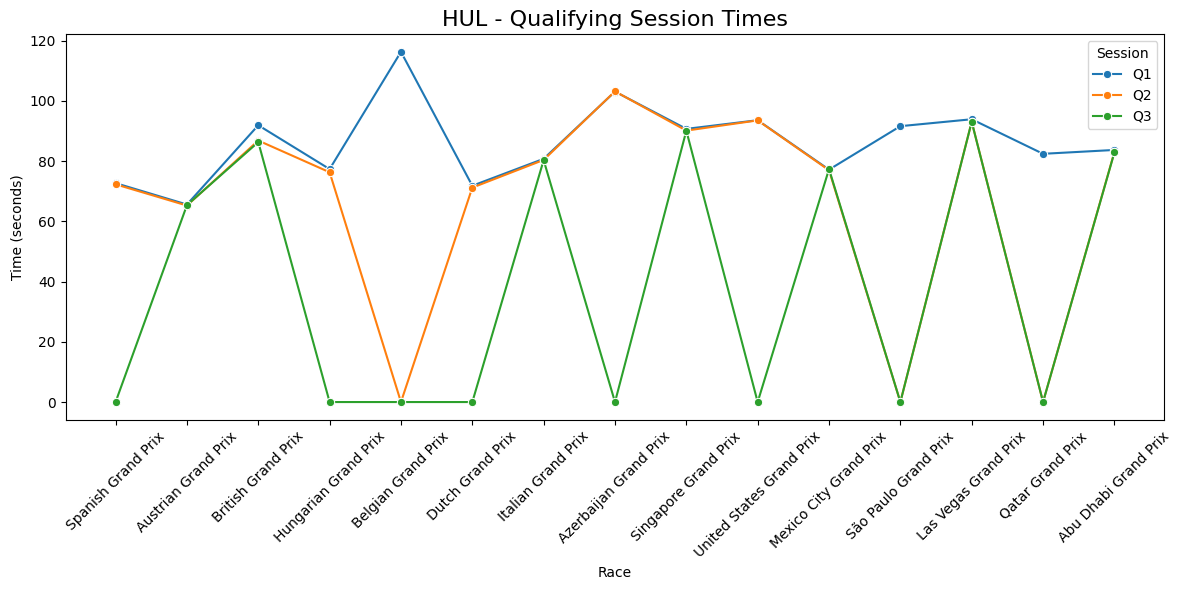

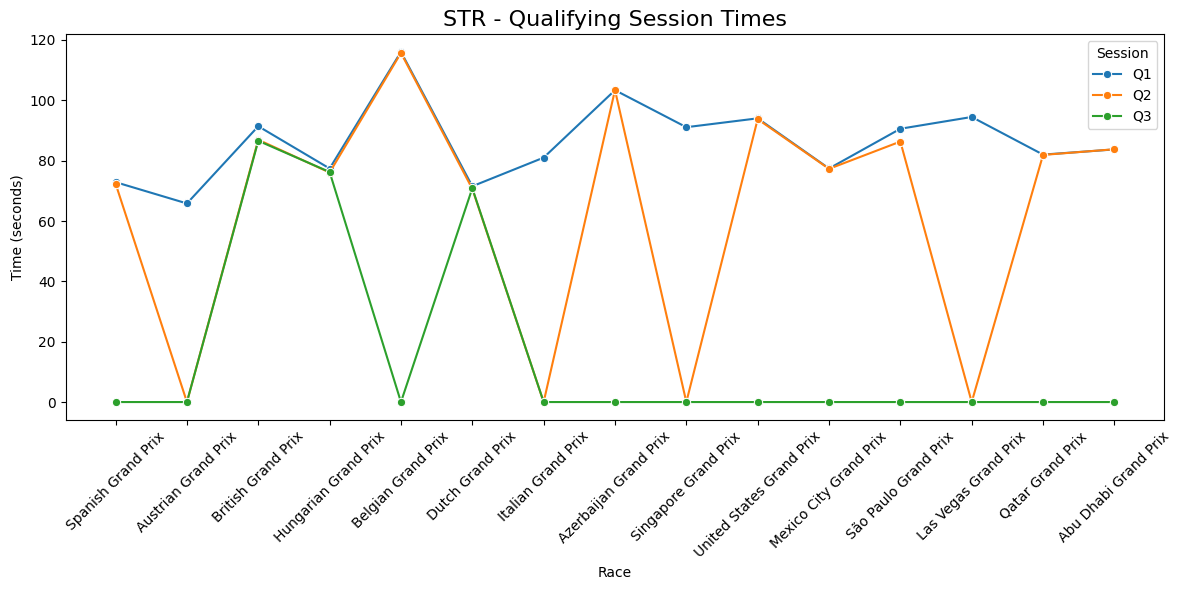

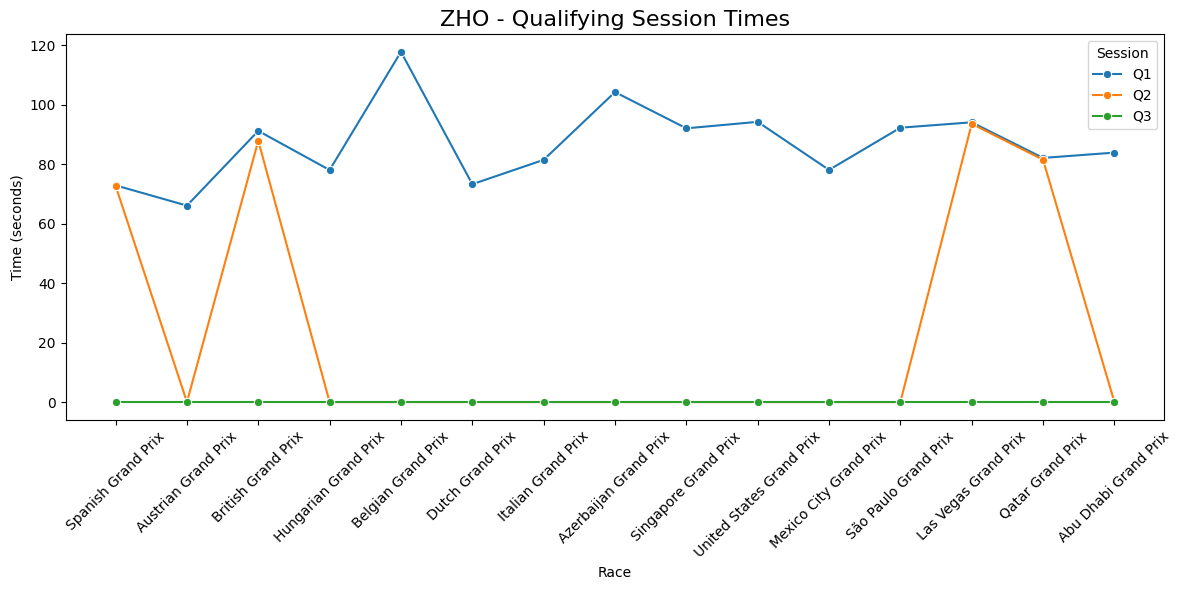

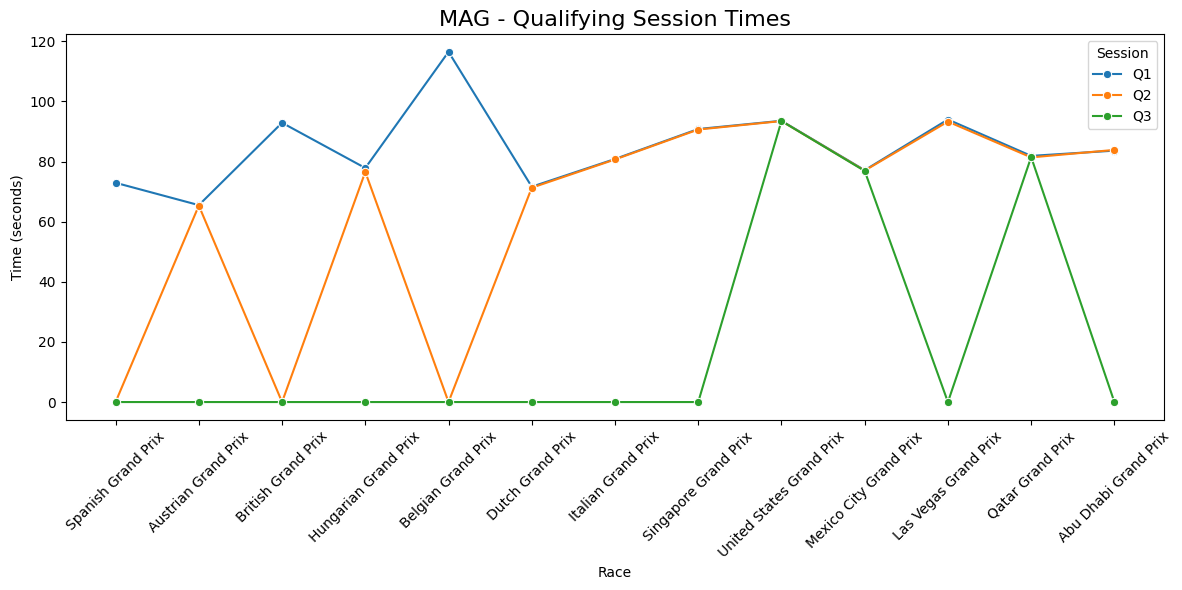

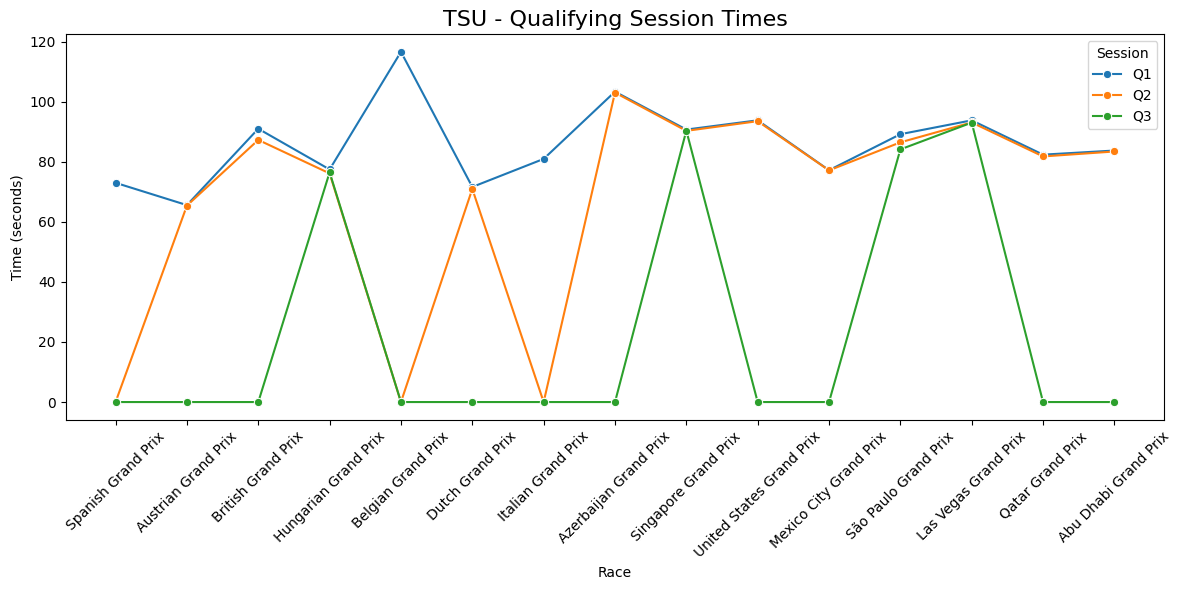

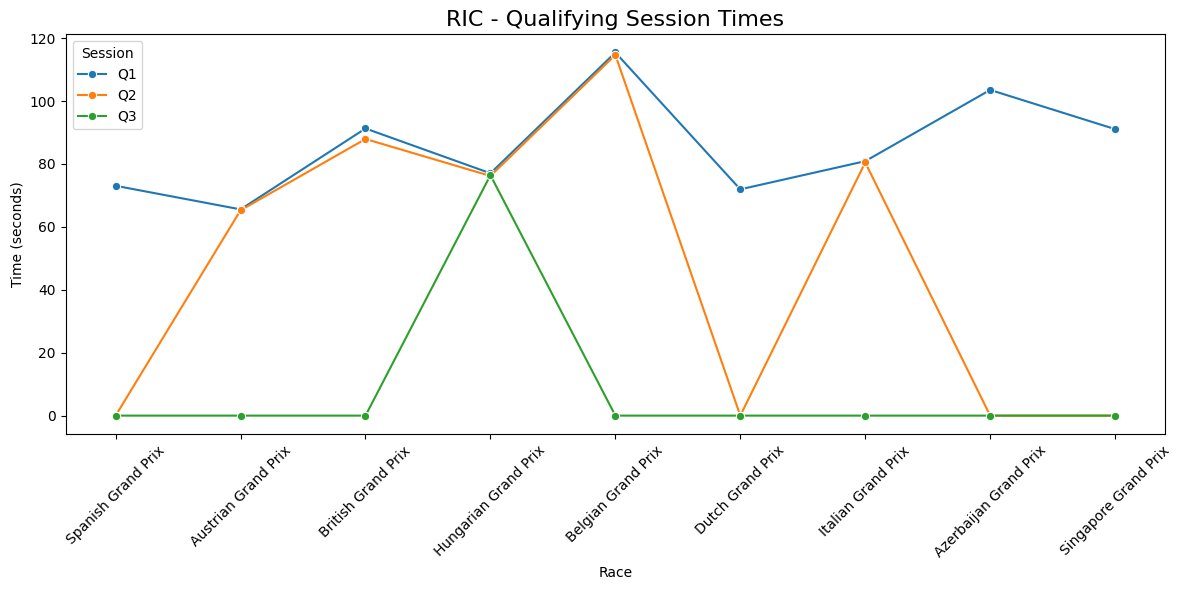

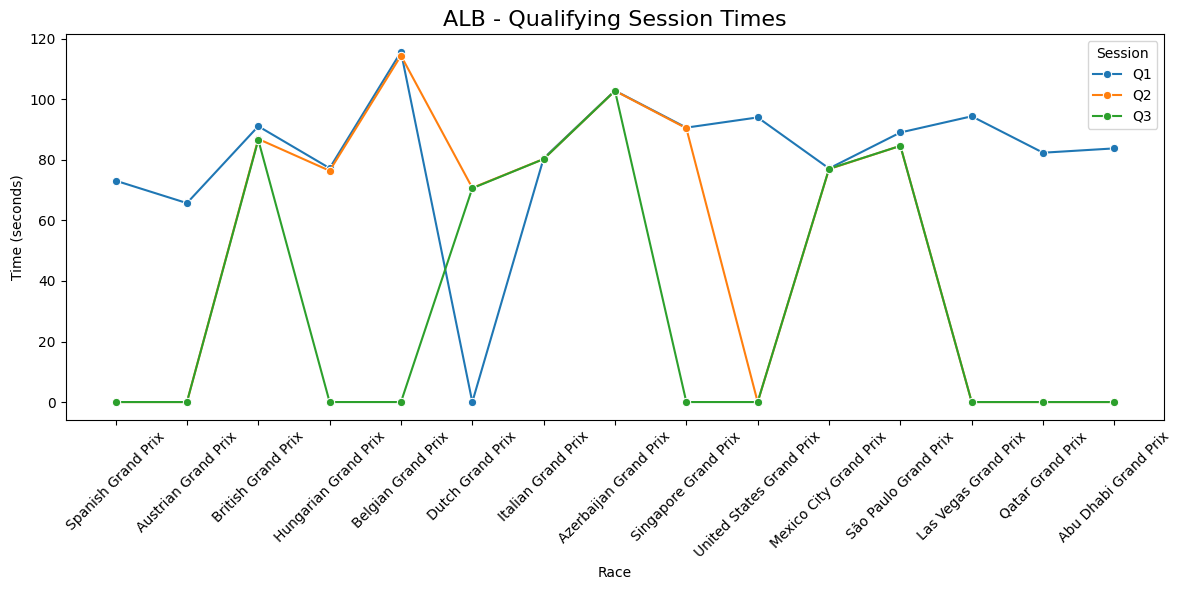

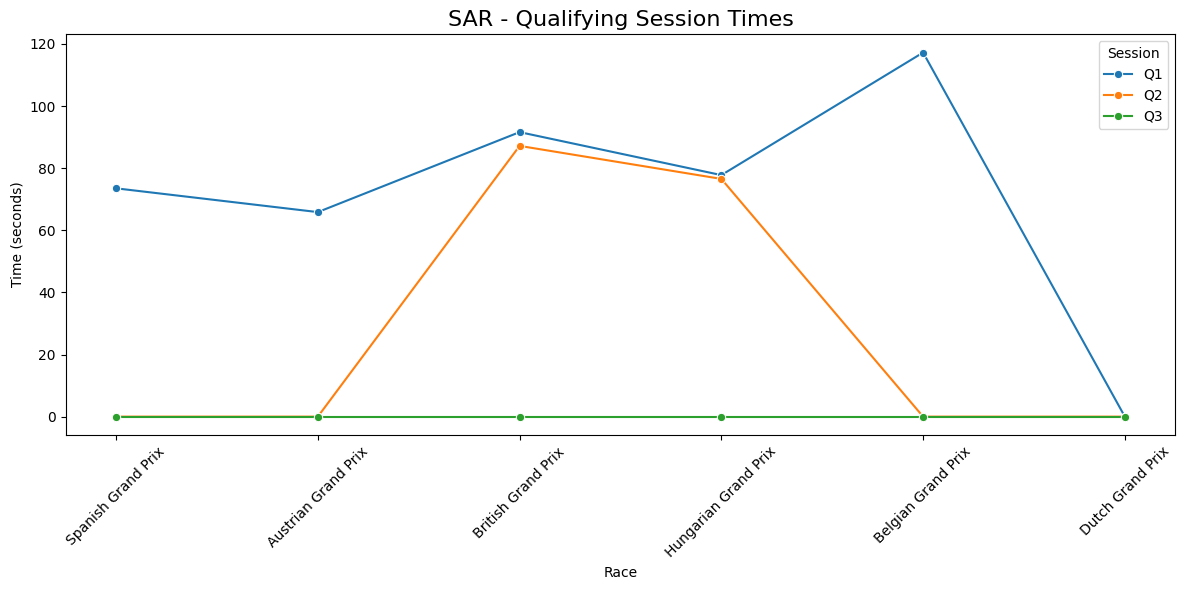

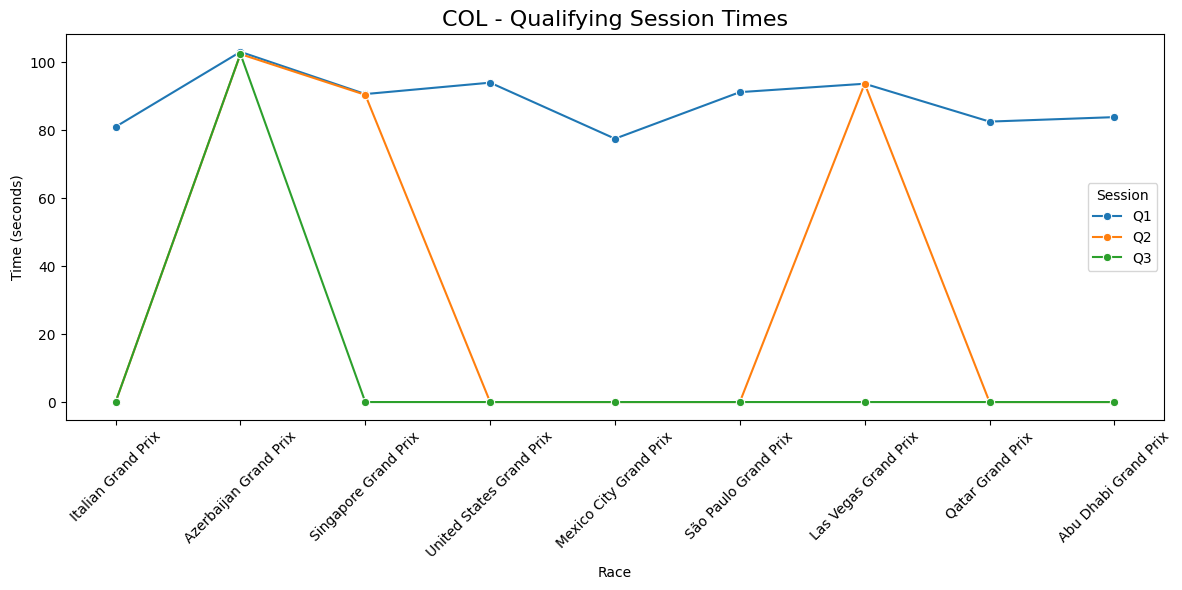

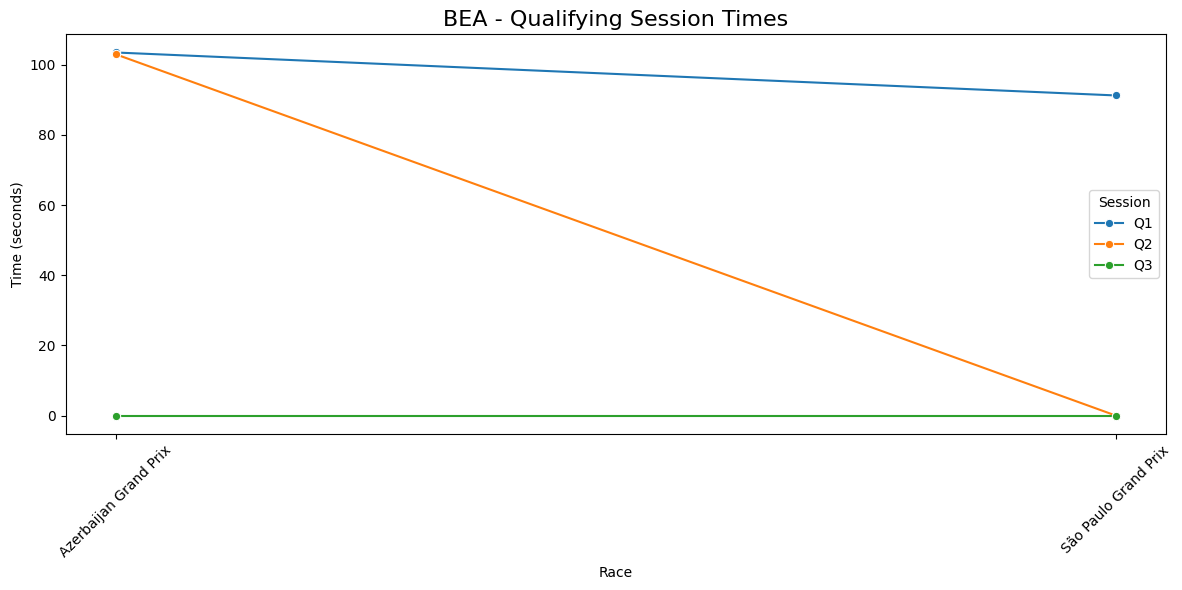

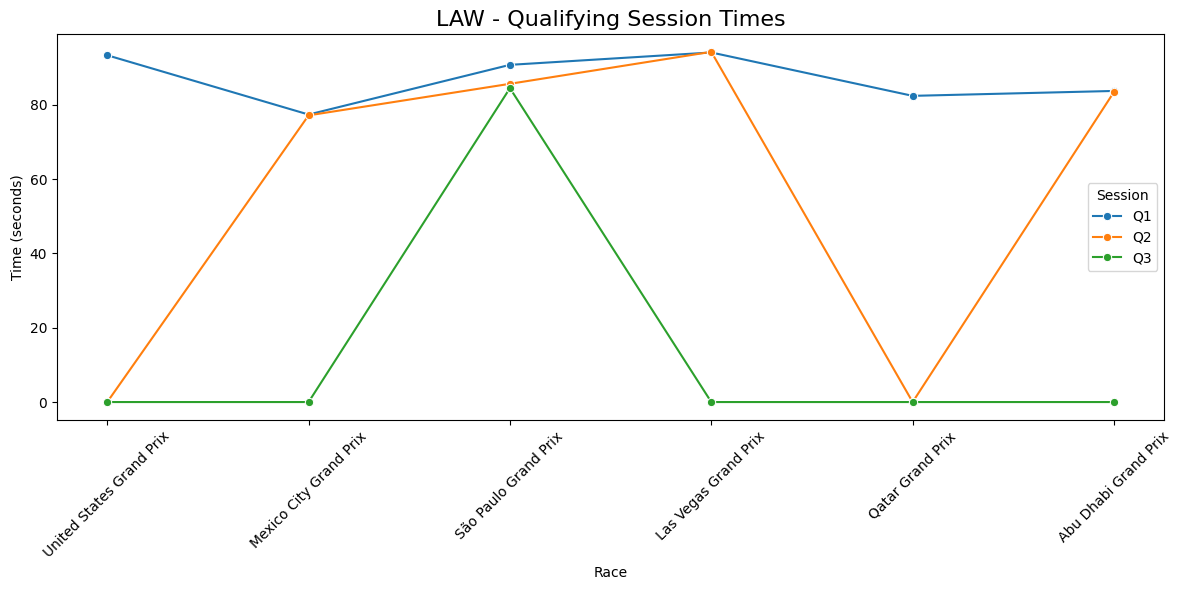

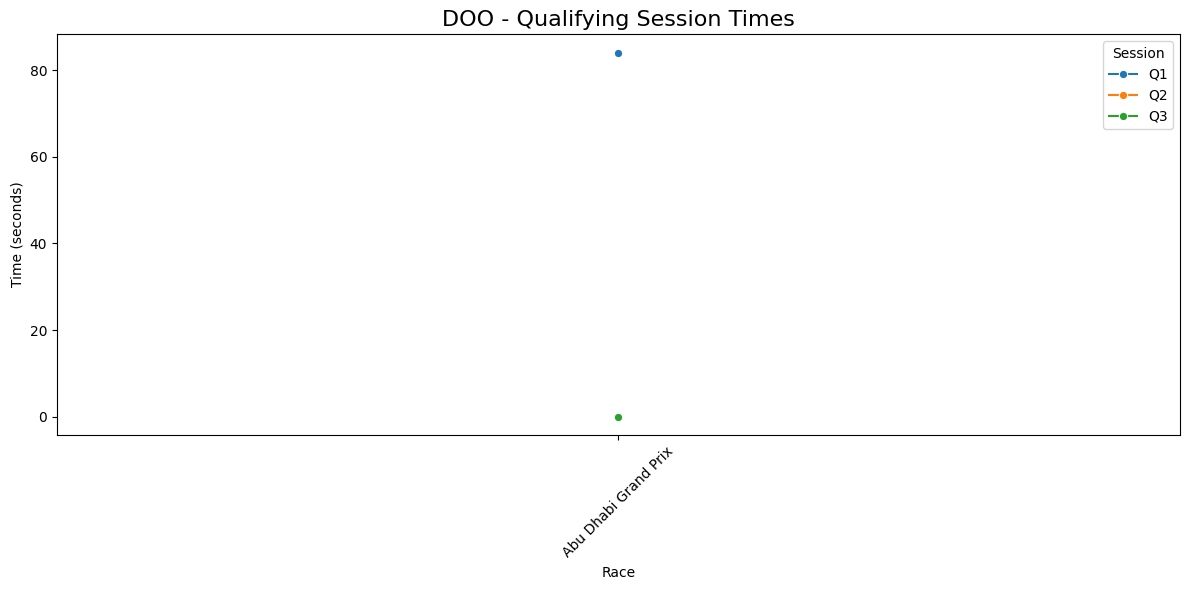

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns 

df_melted = df_qualy.melt(id_vars=["Driver", "Race"], value_vars=["Q1", "Q2", "Q3"],
                          var_name="Session", value_name="Time")

drivers = df_melted["Driver"].unique()


for driver in drivers: 
    plt.figure(figsize=(12,6))
    data = df_melted[df_melted['Driver'] == driver]

    sns.lineplot(data=data, x="Race", y="Time", hue="Session", marker='o')
    plt.title(f"{driver} - Qualifying Session Times", fontsize=16)
    plt.xticks(rotation=45)
    plt.ylabel("Time (seconds)")
    plt.xlabel("Race")
    plt.tight_layout()
    
    plt.show()  # Displays the plot for each driver



In [189]:
df_melted = df_melted[df_melted['Driver'] != "DOO"]


### Model Creation Section
This section outlines the steps to create a linear regression model starting with a single input model from Q1 qualifying in order to predict other sessions 

In [190]:
# Encode the name of the Drivers using one hot encoding 
df_encoded = pd.get_dummies(df_qualy, columns=['Driver'], prefix='Driver', dtype=int)
df_encoded = pd.get_dummies(df_encoded, columns=['Race'], prefix='Race', dtype=int)


df_encoded



,Q1,Q2,Q3,Driver_ALB,Driver_ALO,Driver_BEA,Driver_BOT,Driver_COL,Driver_DOO,Driver_GAS,...,Race_Dutch Grand Prix,Race_Hungarian Grand Prix,Race_Italian Grand Prix,Race_Las Vegas Grand Prix,Race_Mexico City Grand Prix,Race_Qatar Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
0,72.386,71.872,71.383,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,65.450,65.103,64.718,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,91.596,86.559,86.030,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,77.755,75.540,75.227,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,115.582,114.358,113.981,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,90.758,85.654,84.484,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
296,94.087,94.257,0.000,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
297,82.411,0.000,0.000,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
298,83.733,83.472,0.000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [191]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Our X features will include engineered features 
# we need the race number previous qualyfing times, driver name 

# Lets remove the DNF values first 

df_q3_valid = df_encoded[df_encoded['Q3']>0]


y = df_q3_valid['Q3'] # we want to preidct the Q3 

X = df_q3_valid.drop(columns=['Q1', 'Q2', 'Q3'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [192]:
# Creat the linear regression model 
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [193]:
# evaluate the model 
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(10))

Mean Squared Error: 0.5831333324994007
Mean Absolute Error: 0.5980763115518416
R² Score: 0.9971289182838806
      Actual   Predicted
79   114.477  113.477527
268  102.859  101.917834
29    82.945   82.773851
20    70.029   70.079685
49   114.184  113.295388
163   83.196   84.253000
196   86.585   86.665070
151   86.917   87.317639
106   65.202   65.159013
19   113.159  113.371311


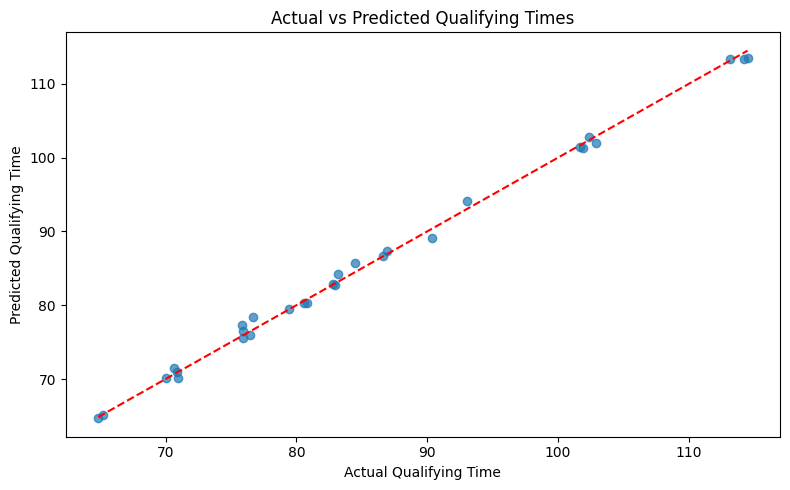

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Qualifying Time")
plt.ylabel("Predicted Qualifying Time")
plt.title("Actual vs Predicted Qualifying Times")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()

In [195]:
print(y.describe())

count    145.000000
mean      84.465828
std       12.621368
min       64.314000
25%       76.043000
50%       82.886000
75%       92.361000
max      114.810000
Name: Q3, dtype: float64


In [196]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("CV R² scores:", scores)
print("Mean R²:", scores.mean())


CV R² scores: [0.99466302 0.96147824 0.9946061  0.99469423 0.992487  ]
Mean R²: 0.9875857184828316


In [197]:
# dropping driver name and testing again 
df_without_driver = df_encoded.drop(columns=df_encoded.columns[df_encoded.columns.str.contains("^Driver_")])


X = df_without_driver.drop(columns=["Q1", "Q2", "Q3"])
y = df_without_driver["Q3"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Retrain the model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# if the score is below 0.99 by alot the model was overfitting to the driver identity
print("R² Score:", r2_score(y_test, y_pred))

R² Score: -0.10853163037254587


### Realization
The model we had was overfitting to the driver identity, after dropping the driver columns from the encoded dataframe, and training the model again we see the R^2 Score drop way below 0.99 to negative values

This means the one-hot encoded driver coluns gave the model unique fingerprints for each driver so taht the model wasnt predicting based on Q1/Q2 performance race or other patterns 
- Essentially it was saying "Oh its norris again, he usually gets 93.3 in Q3" -> memorized

Solution: Adding more engineered features to our model 

In [198]:
df_encoded = df_encoded.drop(columns=['Delta_Q3_Q2'], errors='ignore')

# 1. Feature engineering
df_encoded['Delta_Q2_Q1'] = df_encoded['Q2'] - df_encoded['Q1']


df_encoded['Race_label'] = df['Race']
df_encoded['Q1_position'] = df_encoded.groupby('Race_label')['Q1'].rank()
df_encoded['Q2_position'] = df_encoded.groupby('Race_label')['Q2'].rank()

df_encoded['made_q1'] = (df_encoded['Q1'] > 0).astype(int)
df_encoded['made_q2'] = (df_encoded['Q2'] > 0).astype(int)

def safe_min_max_norm(series):
    min_val, max_val = series.min(), series.max()
    return (series - min_val) / (max_val - min_val) if max_val != min_val else pd.Series([0]*len(series), index=series.index)

df_encoded['Q1_norm'] = safe_min_max_norm(df_encoded['Q1'])
df_encoded['Q2_norm'] = safe_min_max_norm(df_encoded['Q2'])

# 2. Drop string/categorical columns
df_encoded = df_encoded.drop(columns=df_encoded.columns[df_encoded.columns.str.contains("^Driver_")])
df_encoded = df_encoded.drop(columns=['Race_label', 'Race'], errors='ignore')

# 3. Drop target from features
y = df_encoded['Q3']
X = df_encoded.drop(columns=['Q3'])

# 4. Final check: drop string columns
X = X.select_dtypes(exclude=['object', 'string'])

# 5. Train/test split & model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(X.columns[X.columns.str.contains("Q3")])
print(y.describe())
print("R² Score:", r2_score(y_test, y_pred))


Index([], dtype='object')
count    300.000000
mean      40.825150
std       43.177715
min        0.000000
25%        0.000000
50%        0.000000
75%       82.647250
max      114.810000
Name: Q3, dtype: float64
R² Score: -39.06341339098465


In [199]:
mask = df_encoded['Q3'] > 0
df_encoded = df_encoded[mask]

y = df_encoded['Q3']
X = df_encoded.drop(columns=['Q3'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(X.columns[X.columns.str.contains("Q3")])
print(y.describe())
print("R² Score:", r2_score(y_test, y_pred))

Index([], dtype='object')
count    145.000000
mean      84.465828
std       12.621368
min       64.314000
25%       76.043000
50%       82.886000
75%       92.361000
max      114.810000
Name: Q3, dtype: float64
R² Score: 0.998655004738512


Q3                            1.000000
Q2                            0.993974
Q2_norm                       0.993974
Q1_position                   0.948452
Q2_position                   0.906013
Q1                            0.901579
Q1_norm                       0.901579
Race_Belgian Grand Prix       0.640717
Race_Azerbaijan Grand Prix    0.380742
Race_Las Vegas Grand Prix     0.213239
Name: Q3, dtype: float64


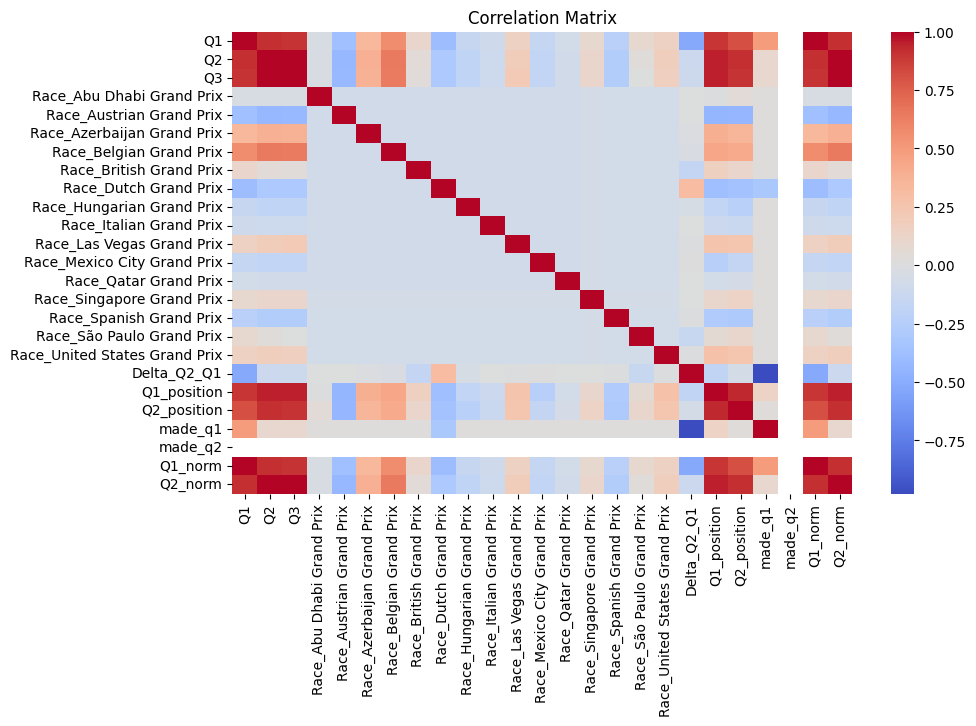

Q2                               2.855889e-01
Race_Belgian Grand Prix          1.890965e-01
Race_Azerbaijan Grand Prix       6.315915e-02
Race_Austrian Grand Prix         5.077666e-02
Race_Dutch Grand Prix            3.948764e-02
Q1_position                      2.287141e-02
Race_Hungarian Grand Prix        1.357242e-02
Race_Mexico City Grand Prix      8.556743e-03
Q1                               7.419584e-03
Race_Las Vegas Grand Prix        4.326452e-03
Race_Qatar Grand Prix            1.984288e-03
Race_Singapore Grand Prix        1.650158e-03
Race_Italian Grand Prix          1.413899e-03
Race_Abu Dhabi Grand Prix        1.016778e-03
Delta_Q2_Q1                      7.333989e-04
Race_British Grand Prix          5.191858e-04
Q2_position                      4.031770e-04
Race_Spanish Grand Prix          0.000000e+00
Race_United States Grand Prix    0.000000e+00
made_q1                          0.000000e+00
made_q2                          0.000000e+00
Q1_norm                         -4

In [200]:
# Check if our model is too accurate
corr = df_encoded.corr(numeric_only=True)['Q3'].sort_values(ascending=False)
print(corr.head(10))  # Are any features almost perfectly correlated with Q3?
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
importances = pd.Series(result.importances_mean, index=X_test.columns)
print(importances.sort_values(ascending=False))


In [201]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("CV R² scores:", scores)
print("Mean:", scores.mean(), "STD:", scores.std())

CV R² scores: [0.99681624 0.95867922 0.99556544 0.99350926 0.96888423]
Mean: 0.9826908778007912 STD: 0.015808229820918826


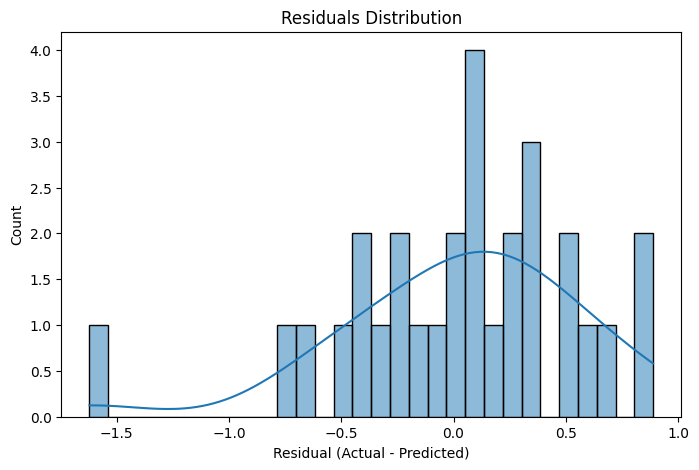

In [202]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

In [203]:
# Restart cleanly
df_model = df_qualy.copy()

# Keep only numeric Q1 and Q3
df_model = df_model[df_model['Q3'] > 0]  # Only valid Q3s
df_model['Q1_norm'] = safe_min_max_norm(df_model['Q1'])
df_model['Q1_position'] = df_model.groupby('Race')['Q1'].rank()

# Create features
df_model['made_q1'] = (df_model['Q1'] > 0).astype(int)

# Encode Race (if you want) - OPTIONAL, but be careful
df_model = pd.get_dummies(df_model, columns=['Race'], prefix='Race', dtype=int)

# Drop string/ID columns
df_model = df_model.drop(columns=['Driver'], errors='ignore')

# Drop Q2 entirely — no delta or Q2 position
df_model = df_model.drop(columns=['Q2'], errors='ignore')

# Train
X = df_model.drop(columns=['Q3'])
y = df_model['Q3']

X = X.select_dtypes(include=['number'])  # Just in case


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))


R² Score: 0.9985703474335303


In [205]:
print([col for col in X.columns if 'Q2' in col])
print(df_model.corr(numeric_only=True)['Q3'].sort_values(ascending=False))



[]
Q3                               1.000000
Q1                               0.901579
Q1_norm                          0.901579
Race_Belgian Grand Prix          0.640717
Race_Azerbaijan Grand Prix       0.380742
Race_Las Vegas Grand Prix        0.213239
Race_United States Grand Prix    0.171853
Race_Singapore Grand Prix        0.105357
made_q1                          0.091516
Race_British Grand Prix          0.040269
Race_São Paulo Grand Prix        0.006196
Q1_position                     -0.004662
Race_Abu Dhabi Grand Prix       -0.032078
Race_Qatar Grand Prix           -0.075480
Race_Italian Grand Prix         -0.102334
Race_Mexico City Grand Prix     -0.170515
Race_Hungarian Grand Prix       -0.186618
Race_Spanish Grand Prix         -0.260185
Race_Dutch Grand Prix           -0.303854
Race_Austrian Grand Prix        -0.420807
Name: Q3, dtype: float64


### Realization 2 
Theres been an issue, we notice that even with adding engineered features we are running into an issue. The fact that the R2 score is very close to 0.99 even with engineered features and also having removed the driver identity. This is because we realized that if a driver is doing well in Q1 and Q2 they are bound to do well in Q3 as well so the numbers are quite similar thus the correlation when trying to predict will also be very similar 

- Something we can do is shift towards classification model, so we can connect the dots instead 
- Not learning from patterns just exploiting the obvious ones 


In [ ]:
# Goal predict if the driver makes it to Q3 or not binary 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

df_classification = df_qualy.copy()

df_classification

# target class
df_classification['made_q3'] = (df_classification['Q3'] > 0).astype(int) 

# dropping columns 
df_classification = df_classification.drop(["Q2", "Q3"])
df_classification = df_classification[df_classification['Q1'] > 0]


# Feature engineering

def safe_min_max_norm(series):
    min_val, max_val = series.min(), series.max()
    return (series - min_val) / (max_val - min_val) if max_val != min_val else pd.Series([0]*len(series), index=series.index)

df_classification['Q1_norm'] = safe_min_max_norm(df_classification['Q1'])


# one hot encoding the categorical variables (Driver and race)
df_classification = pd.get_dummies(df_classification, columns=['Driver', 'Race'], drop_first=True)

# Create the calssification pipiline 
X = df_model.drop(columns=['Q1', 'made_q3'])
y = df_model['made_q3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

